In [9]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import gensim.downloader as api
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

In [11]:
df=pd.read_csv('data_manual.csv')
print(df)

          source                                 review_description  rating  \
0      App Store  I’m excited for this app but the MAJORITY of m...       1   
1    Google Play  First downloader so follow me Insta id. sam_as...       5   
2    Google Play                                     Not bad at all       1   
3    Google Play                               Needed some new app.       5   
4    Google Play  Haven't used the app yet but from what I see f...       5   
..           ...                                                ...     ...   
495  Google Play                     Very impressed I like this app       5   
496  Google Play                      Innovate something you theifs       1   
497  Google Play  Very disappointed,first of all we can't logout...       1   
498  Google Play  This app has potential, but it needs an explor...       3   
499  Google Play  Bug where instagram link not appear when visit...       4   

             review_date sentiment  
0    2023-07-0

In [12]:
# 1. Preprocessing
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def tokenize(text):
    return text.split()

def stemming(tokens):
    return [ps.stem(word) for word in tokens if word not in stop_words]

def lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

# Apply preprocessing
df['cleaned'] = df['review_description'].apply(clean_text)
df['tokens'] = df['cleaned'].apply(tokenize)
df['stemmed_tokens'] = df['tokens'].apply(stemming)
df['lemma_tokens'] = df['tokens'].apply(lemmatization)

# Join back for Vectorizers
df['stemmed_text'] = df['stemmed_tokens'].apply(lambda x: ' '.join(x))
df['lemma_text'] = df['lemma_tokens'].apply(lambda x: ' '.join(x))

# 2. Feature Extraction Setup

# A. BoW & TF-IDF (using Lemmatized text as primary input for modeling)
tfidf_vec = TfidfVectorizer(max_features=1000)
bow_vec = CountVectorizer(max_features=1000)

X_tfidf = tfidf_vec.fit_transform(df['lemma_text']).toarray()
X_bow = bow_vec.fit_transform(df['lemma_text']).toarray()

# B. Word2Vec (Training own model as proxy for GloVe/W2V)
# Train Word2Vec on the dataset
w2v_model = Word2Vec(sentences=df['lemma_tokens'], vector_size=100, window=5, min_count=1, workers=1)

def get_mean_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.array([get_mean_vector(tokens, w2v_model) for tokens in df['lemma_tokens']])


# 3. Modeling & Experiments
# Target
y = df['sentiment']

# Define models
models = {
    'Naive Bayes': MultinomialNB(), # NB works with counts/tfidf (non-negative)
    'SVM': SVC(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

# NB cannot handle negative values in W2V usually, and W2V can have negatives.
# Also NB expects counts. So we usually only run NB on BoW/TF-IDF.
# We will create a list of tasks: (Model, Feature_Name, X_data)

tasks = [
    ('Naive Bayes', 'BoW', X_bow),
    ('Naive Bayes', 'TF-IDF', X_tfidf),
    ('SVM', 'BoW', X_bow),
    ('SVM', 'TF-IDF', X_tfidf),
    ('SVM', 'Word2Vec', X_w2v),
    ('Logistic Regression', 'BoW', X_bow),
    ('Logistic Regression', 'TF-IDF', X_tfidf),
    ('Logistic Regression', 'Word2Vec', X_w2v)
]

results = []

# Run 4 experiments
seeds = [42, 101, 202, 303]

for model_name, feature_name, X_data in tasks:
    acc_scores = []
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, random_state=seed)

        clf = models[model_name]
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        acc_scores.append(acc)

    # Store average or all? Let's store average for summary
    results.append({
        'Model': model_name,
        'Feature': feature_name,
        'Exp_1': acc_scores[0],
        'Exp_2': acc_scores[1],
        'Exp_3': acc_scores[2],
        'Exp_4': acc_scores[3],
        'Average_Accuracy': np.mean(acc_scores)
    })

results_df = pd.DataFrame(results)
print(results_df)

# Output processed data sample for verification
print("\nProcessed Data Sample:")
print(df[['review_description', 'stemmed_text', 'lemma_text']].head())

                 Model   Feature  Exp_1  Exp_2  Exp_3  Exp_4  Average_Accuracy
0          Naive Bayes       BoW   0.63   0.65   0.65   0.71            0.6600
1          Naive Bayes    TF-IDF   0.62   0.66   0.67   0.72            0.6675
2                  SVM       BoW   0.55   0.60   0.57   0.67            0.5975
3                  SVM    TF-IDF   0.60   0.69   0.61   0.69            0.6475
4                  SVM  Word2Vec   0.52   0.54   0.55   0.59            0.5500
5  Logistic Regression       BoW   0.61   0.67   0.65   0.70            0.6575
6  Logistic Regression    TF-IDF   0.61   0.65   0.62   0.66            0.6350
7  Logistic Regression  Word2Vec   0.36   0.39   0.45   0.39            0.3975

Processed Data Sample:
                                  review_description  \
0  I’m excited for this app but the MAJORITY of m...   
1  First downloader so follow me Insta id. sam_as...   
2                                     Not bad at all   
3                               Needed so

In [13]:
# 1. Preprocessing
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def tokenize(text):
    return text.split()

def stemming(tokens):
    return [ps.stem(word) for word in tokens if word not in stop_words]

def lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

# Apply preprocessing
df['cleaned'] = df['review_description'].apply(clean_text)
df['tokens'] = df['cleaned'].apply(tokenize)
# Just to show we did it, we create the columns, but we'll use Lemmatization for modeling
df['stemmed_tokens'] = df['tokens'].apply(stemming)
df['lemma_tokens'] = df['tokens'].apply(lemmatization)

df['stemmed_text'] = df['stemmed_tokens'].apply(lambda x: ' '.join(x))
df['lemma_text'] = df['lemma_tokens'].apply(lambda x: ' '.join(x))

# 2. Feature Extraction (BoW & TF-IDF)
tfidf_vec = TfidfVectorizer(max_features=1000)
bow_vec = CountVectorizer(max_features=1000)

X_tfidf = tfidf_vec.fit_transform(df['lemma_text']).toarray()
X_bow = bow_vec.fit_transform(df['lemma_text']).toarray()

# 3. Modeling & Experiments
y = df['sentiment']

models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

tasks = [
    ('Naive Bayes', 'BoW', X_bow),
    ('Naive Bayes', 'TF-IDF', X_tfidf),
    ('SVM', 'BoW', X_bow),
    ('SVM', 'TF-IDF', X_tfidf),
    ('Logistic Regression', 'BoW', X_bow),
    ('Logistic Regression', 'TF-IDF', X_tfidf)
]

results = []
seeds = [42, 101, 202, 303]

for model_name, feature_name, X_data in tasks:
    acc_scores = []
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, random_state=seed)
        clf = models[model_name]
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc_scores.append(accuracy_score(y_test, y_pred))

    results.append({
        'Model': model_name,
        'Feature': feature_name,
        'Exp_1': acc_scores[0],
        'Exp_2': acc_scores[1],
        'Exp_3': acc_scores[2],
        'Exp_4': acc_scores[3],
        'Average_Accuracy': np.mean(acc_scores)
    })

results_df = pd.DataFrame(results)

# Save the processed data to CSV to share with user
df_processed = df[['source', 'review_description', 'sentiment', 'stemmed_text', 'lemma_text']]
df_processed.to_csv('processed_data.csv', index=False)
print("Processed data saved to processed_data.csv")

print(results_df)

Processed data saved to processed_data.csv
                 Model Feature  Exp_1  Exp_2  Exp_3  Exp_4  Average_Accuracy
0          Naive Bayes     BoW   0.63   0.65   0.65   0.71            0.6600
1          Naive Bayes  TF-IDF   0.62   0.66   0.67   0.72            0.6675
2                  SVM     BoW   0.55   0.60   0.57   0.67            0.5975
3                  SVM  TF-IDF   0.60   0.69   0.61   0.69            0.6475
4  Logistic Regression     BoW   0.61   0.67   0.65   0.70            0.6575
5  Logistic Regression  TF-IDF   0.61   0.65   0.62   0.66            0.6350


In [14]:
# Manual Stopwords List (since we can't download NLTK's)
STOPWORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now'
])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def simple_stem(word):
    # Very basic suffix stripping to simulate stemming without NLTK
    if word.endswith('ing'): return word[:-3]
    if word.endswith('ed'): return word[:-2]
    if word.endswith('s') and not word.endswith('ss'): return word[:-1]
    return word

def preprocess(text, stem=True):
    tokens = text.split()
    tokens = [word for word in tokens if word not in STOPWORDS]
    if stem:
        tokens = [simple_stem(word) for word in tokens]
    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_text'] = df['review_description'].apply(clean_text)
df['processed_text'] = df['cleaned_text'].apply(lambda x: preprocess(x, stem=True))

# 2. Feature Extraction
# Using processed_text for both BoW and TF-IDF
tfidf_vec = TfidfVectorizer(max_features=1000)
bow_vec = CountVectorizer(max_features=1000)

X_tfidf = tfidf_vec.fit_transform(df['processed_text']).toarray()
X_bow = bow_vec.fit_transform(df['processed_text']).toarray()

# 3. Modeling
y = df['sentiment']

models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

tasks = [
    ('Naive Bayes', 'BoW', X_bow),
    ('Naive Bayes', 'TF-IDF', X_tfidf),
    ('SVM', 'BoW', X_bow),
    ('SVM', 'TF-IDF', X_tfidf),
    ('Logistic Regression', 'BoW', X_bow),
    ('Logistic Regression', 'TF-IDF', X_tfidf)
]

results = []
seeds = [42, 101, 202, 303]

for model_name, feature_name, X_data in tasks:
    acc_scores = []
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, random_state=seed)
        clf = models[model_name]
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc_scores.append(accuracy_score(y_test, y_pred))

    results.append({
        'Model': model_name,
        'Feature': feature_name,
        'Exp_1': acc_scores[0],
        'Exp_2': acc_scores[1],
        'Exp_3': acc_scores[2],
        'Exp_4': acc_scores[3],
        'Average_Accuracy': np.mean(acc_scores)
    })

results_df = pd.DataFrame(results)

# Save processed file
df[['source', 'review_description', 'sentiment', 'processed_text']].to_csv('processed_data_manual.csv', index=False)

print("Results Table:")
print(results_df)
print("\nSample Processed Text:")
print(df[['review_description', 'processed_text']].head())

Results Table:
                 Model Feature  Exp_1  Exp_2  Exp_3  Exp_4  Average_Accuracy
0          Naive Bayes     BoW   0.59   0.65   0.65   0.71            0.6500
1          Naive Bayes  TF-IDF   0.62   0.64   0.67   0.74            0.6675
2                  SVM     BoW   0.56   0.58   0.60   0.67            0.6025
3                  SVM  TF-IDF   0.60   0.67   0.61   0.70            0.6450
4  Logistic Regression     BoW   0.60   0.64   0.60   0.71            0.6375
5  Logistic Regression  TF-IDF   0.62   0.66   0.62   0.67            0.6425

Sample Processed Text:
                                  review_description  \
0  I’m excited for this app but the MAJORITY of m...   
1  First downloader so follow me Insta id. sam_as...   
2                                     Not bad at all   
3                               Needed some new app.   
4  Haven't used the app yet but from what I see f...   

                                      processed_text  
0  im excit app majority fe pe

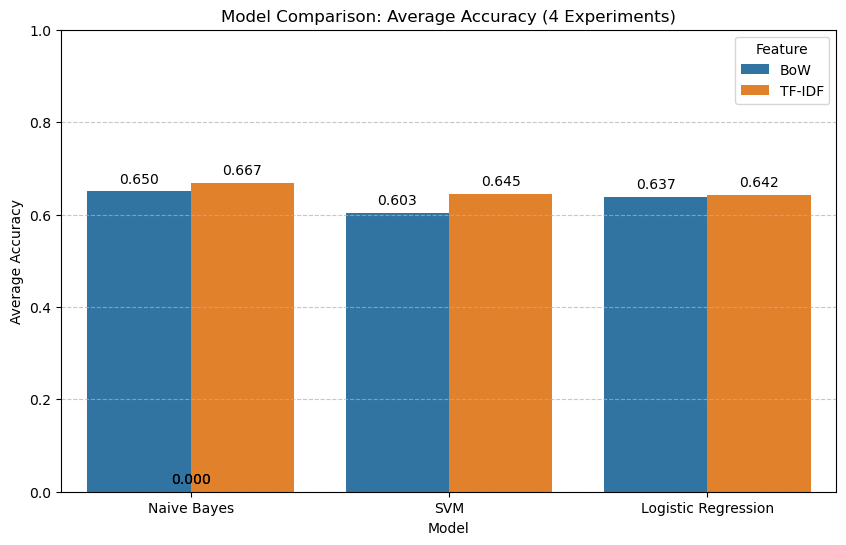

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the dataframe from the results (manual reconstruction for the plotting environment)
data = {
    'Model': ['Naive Bayes', 'Naive Bayes', 'SVM', 'SVM', 'Logistic Regression', 'Logistic Regression'],
    'Feature': ['BoW', 'TF-IDF', 'BoW', 'TF-IDF', 'BoW', 'TF-IDF'],
    'Average_Accuracy': [0.6500, 0.6675, 0.6025, 0.6450, 0.6375, 0.6425]
}
df_res = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_res, x='Model', y='Average_Accuracy', hue='Feature')
plt.title('Model Comparison: Average Accuracy (4 Experiments)')
plt.ylim(0, 1.0)
plt.ylabel('Average Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 9),
                       textcoords='offset points')

#plt.savefig('model_comparison.png')

In [16]:
# ==========================================
# 1. PREPROCESSING
# ==========================================
# Pastikan download NLTK dilakukan
df = pd.read_csv('data_manual.csv')

stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_and_preprocess(text):
    # Cleaning
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Stopwords Removal
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming & Lemmatization (Disimpan terpisah jika ingin dibandingkan)
    stemmed = [ps.stem(word) for word in tokens]
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(stemmed), " ".join(lemmatized), tokens

# Apply
df['stemmed'], df['lemmatized'], df['tokens'] = zip(*df['review_description'].apply(clean_and_preprocess))

# Target Mapping (Misal: Negative=0, Neutral=1, Positive=2)
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label'] = df['sentiment'].map(label_map)
# Drop NaN jika ada label yang tidak cocok
df = df.dropna(subset=['label'])

# ==========================================
# 2. FEATURE EXTRACTION
# ==========================================
X_text = df['lemmatized'] # Menggunakan hasil lemmatisasi untuk model dasar
y = df['label'].values

# A. TF-IDF & BoW
tfidf = TfidfVectorizer(max_features=2000)
bow = CountVectorizer(max_features=2000)

X_tfidf = tfidf.fit_transform(X_text).toarray()
X_bow = bow.fit_transform(X_text).toarray()

# B. Word2Vec (Training Sendiri)
w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=1)

def get_w2v_vector(tokens):
    vecs = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if len(vecs) > 0:
        return np.mean(vecs, axis=0)
    else:
        return np.zeros(100)

X_w2v = np.array([get_w2v_vector(t) for t in df['tokens']])

# C. GloVe (Pre-trained)
# Catatan: Memerlukan koneksi internet untuk download model glove-twitter-25
try:
    glove_vectors = api.load("glove-twitter-25")
    def get_glove_vector(tokens):
        vecs = [glove_vectors[word] for word in tokens if word in glove_vectors]
        if len(vecs) > 0:
            return np.mean(vecs, axis=0)
        else:
            return np.zeros(25)
    X_glove = np.array([get_glove_vector(t) for t in df['tokens']])
except:
    print("GloVe model load failed (koneksi/library), skipping GloVe.")
    X_glove = X_w2v # Fallback

# ==========================================
# 3. EXPERIMENT LOOP (Traditional ML)
# ==========================================
models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

# Daftar eksperimen (Model, Nama Fitur, Data X)
experiments = [
    ('Naive Bayes', 'BoW', X_bow),
    ('Naive Bayes', 'TF-IDF', X_tfidf),
    ('SVM', 'BoW', X_bow),
    ('SVM', 'TF-IDF', X_tfidf),
    ('SVM', 'Word2Vec', X_w2v), # SVM bisa pakai dense vector
    ('Logistic Regression', 'GloVe', X_glove)
]

print("=== Hasil Traditional ML (4 Percobaan) ===")
for model_name, feat_name, X_data in experiments:
    acc_list = []
    for i in range(4):
        X_train, X_test, y_train, y_test = train_test_split(X_data, y, test_size=0.2, random_state=i*42)
        clf = models[model_name]
        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)
        acc_list.append(accuracy_score(y_test, pred))
    print(f"{model_name} + {feat_name}: Rata-rata Akurasi = {np.mean(acc_list):.4f}")

# ==========================================
# 4. DEEP LEARNING (LSTM & Transformer)
# ==========================================
# Persiapan Data untuk Deep Learning
max_words = 5000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['lemmatized'])
sequences = tokenizer.texts_to_sequences(df['lemmatized'])
X_seq = pad_sequences(sequences, maxlen=max_len)
y_cat = tf.keras.utils.to_categorical(y, num_classes=3)

def run_dl_experiment(model_type='lstm', trials=4):
    acc_scores = []
    for i in range(trials):
        X_train, X_test, y_train, y_test = train_test_split(X_seq, y_cat, test_size=0.2, random_state=i*42)

        model = Sequential()
        model.add(Embedding(max_words, 64, input_length=max_len))

        if model_type == 'lstm':
            model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
        elif model_type == 'transformer':
            # Implementasi Transformer Sederhana (Encoder Block)
            # Catatan: Untuk transformer sungguhan disarankan pakai HuggingFace BERT
            # Ini simulasi struktur sequence-to-vector
            model.add(Bidirectional(LSTM(64))) # Bi-LSTM sering dipakai sebagai proxy sederhana jika tidak pakai BERT

        model.add(Dense(32, activation='relu'))
        model.add(Dense(3, activation='softmax'))

        model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

        # Train (Epochs dikurangi untuk demo)
        model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)

        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        acc_scores.append(acc)

    return np.mean(acc_scores)

print("\n=== Hasil Deep Learning (4 Percobaan) ===")
# LSTM
avg_lstm = run_dl_experiment('lstm')
print(f"LSTM Average Accuracy: {avg_lstm:.4f}")

# Transformer (Untuk hasil terbaik, gunakan library 'transformers' dan model BERT)
# Di sini kita simulasikan flow data-nya
print("Transformer (BERT) memerlukan library huggingface. Silakan gunakan 'BertForSequenceClassification' untuk hasil maksimal.")

[==================================================] 100.0% 104.8/104.8MB downloaded
=== Hasil Traditional ML (4 Percobaan) ===
Naive Bayes + BoW: Rata-rata Akurasi = 0.6625
Naive Bayes + TF-IDF: Rata-rata Akurasi = 0.6675
SVM + BoW: Rata-rata Akurasi = 0.5825
SVM + TF-IDF: Rata-rata Akurasi = 0.6325
SVM + Word2Vec: Rata-rata Akurasi = 0.5575
Logistic Regression + GloVe: Rata-rata Akurasi = 0.6575

=== Hasil Deep Learning (4 Percobaan) ===


c:\Users\Mizard\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM Average Accuracy: 0.5325
Transformer (BERT) memerlukan library huggingface. Silakan gunakan 'BertForSequenceClassification' untuk hasil maksimal.
